<a href="https://colab.research.google.com/github/AleximperV/ThucHanhDeepLearning/blob/main/Tuan_4/CNNBai2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nạp thư viện

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Tải bộ dữ liệu từ Tensorflow

In [ ]:
(raw_train, raw_val, raw_test), info = tfds.load(
    "cats_vs_dogs",
    split=[
        "train[:80%]",
        "train[80%:90%]",
        "train[90%:]"
    ],
    as_supervised=True,
    with_info=True
)

print(info)
print("Tên lớp:", info.features["label"].names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.ZURPO1_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

Khai báo kích thước ảnh và tiền xử lý dữ liệu

In [ ]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = ["cat", "dog"]

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return image, label

train_ds = raw_train.map(preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = raw_val.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = raw_test.map(preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

Hiển thị một vài ảnh

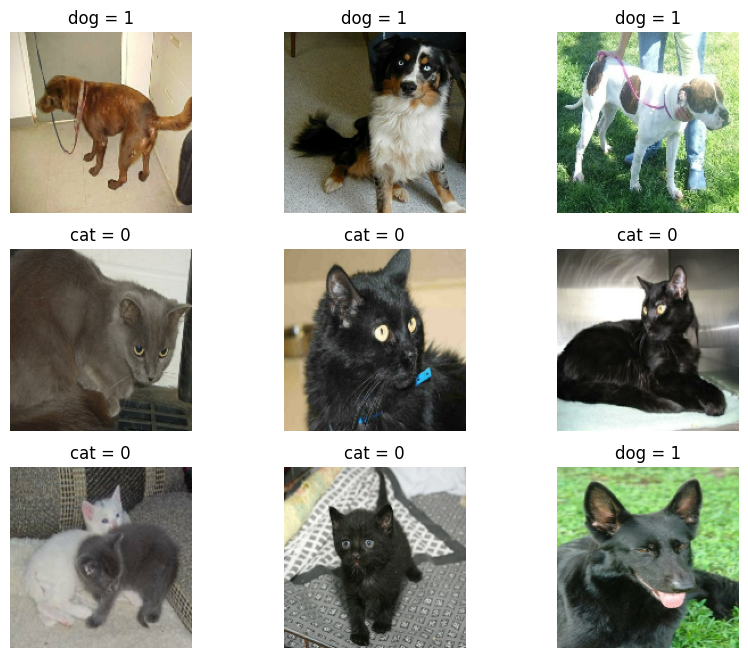

In [ ]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        label_id = int(labels[i].numpy())
        plt.title(f"{CLASS_NAMES[label_id]} = {label_id}")
        plt.axis("off")

plt.show()

Tăng cường dữ liệu

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

Xây dựng mô hình CNN

In [ ]:
model = models.Sequential([
    layers.Input(shape=(160, 160, 3)),

    data_augmentation,

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,879,489 (7.17 MB)

 Trainable params: 1,879,489 (7.17 MB)

 Non-trainable params: 0 (0.00 B)

Compile mô hình

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Huấn luyện mô hình CNN

In [ ]:
EPOCHS = 25

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/25
582/582 ━━━━━━━━━━━━━━━━━━━━ 1320s 2s/step - accuracy: 0.6010 - loss: 0.6560 - val_accuracy: 0.6655 - val_loss: 0.6344
Epoch 2/25
582/582 ━━━━━━━━━━━━━━━━━━━━ 1326s 2s/step - accuracy: 0.6997 - loss: 0.5794 - val_accuracy: 0.7524 - val_loss: 0.5239
Epoch 3/25
443/582 ━━━━━━━━━━━━━━━━━━━━ 4:58 2s/step - accuracy: 0.7306 - loss: 0.5400

Vẽ biểu đồ Accuracy và Loss

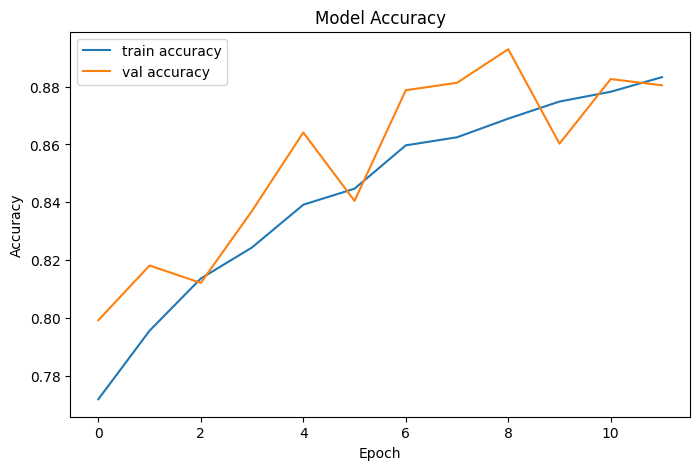

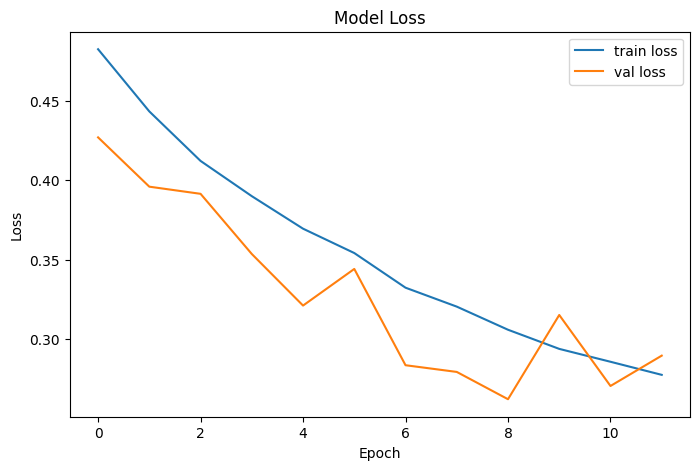

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Đánh giá mô hình trên tập test

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

73/73 - 4s - 48ms/step - accuracy: 0.8882 - loss: 0.2617
Test loss: 0.2616991400718689
Test accuracy: 0.8882201313972473


Dự báo một batch ảnh test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


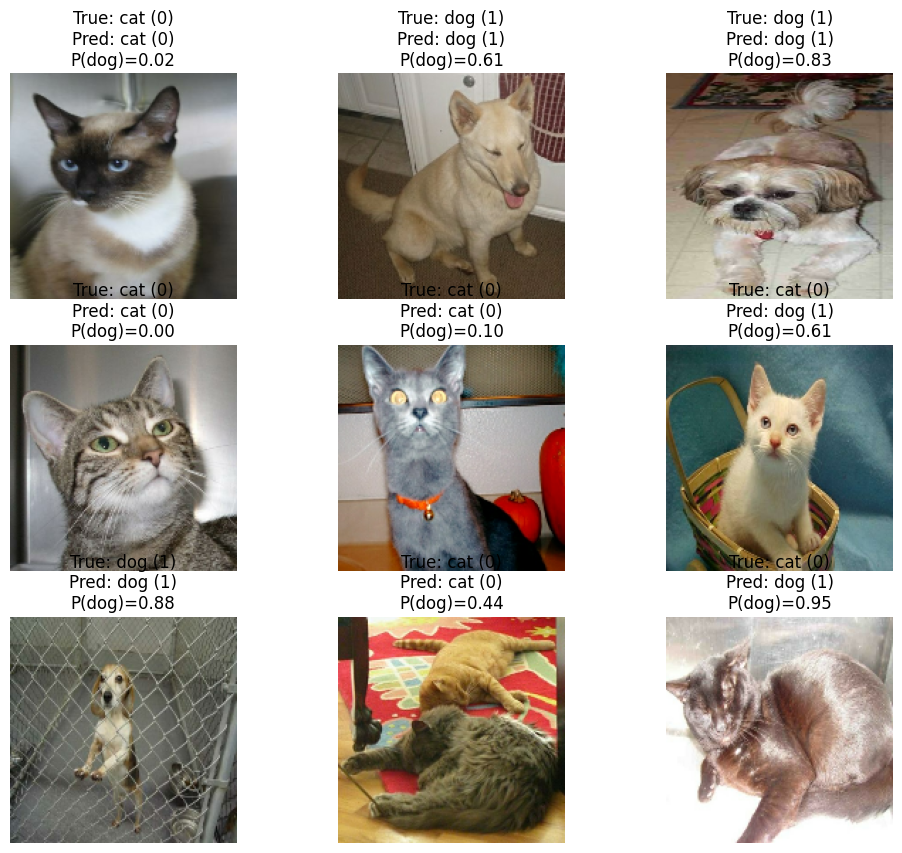

In [ ]:
plt.figure(figsize=(12, 10))

for images, labels in test_ds.take(1):
    probs = model.predict(images)
    preds = (probs >= 0.5).astype(int).reshape(-1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        true_label = int(labels[i].numpy())
        pred_label = int(preds[i])
        prob_dog = float(probs[i][0])

        plt.title(
            f"True: {CLASS_NAMES[true_label]} ({true_label})\n"
            f"Pred: {CLASS_NAMES[pred_label]} ({pred_label})\n"
            f"P(dog)={prob_dog:.2f}"
        )
        plt.axis("off")

plt.show()

Dự đoán ảnh tự upload lên Colab

Saving z7889188205136_d0d712fde4e34f38dbfc4b6de5f90320.jpg to z7889188205136_d0d712fde4e34f38dbfc4b6de5f90320 (1).jpg


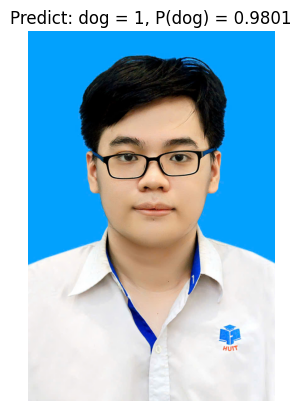

Kết quả nhị phân:
cat = 0, dog = 1
Dự đoán: dog
Nhãn dự đoán: 1
Xác suất dog: 0.98011553


In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

image_path = next(iter(uploaded))

def predict_one_image(path):
    img = load_img(path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob_dog = model.predict(img_array, verbose=0)[0][0]
    pred_label = int(prob_dog >= 0.5)
    pred_name = CLASS_NAMES[pred_label]

    plt.imshow(load_img(path))
    plt.axis("off")
    plt.title(f"Predict: {pred_name} = {pred_label}, P(dog) = {prob_dog:.4f}")
    plt.show()

    print("Kết quả nhị phân:")
    print("cat = 0, dog = 1")
    print("Dự đoán:", pred_name)
    print("Nhãn dự đoán:", pred_label)
    print("Xác suất dog:", prob_dog)

predict_one_image(image_path)

Lưu mô hình

In [ ]:
model.save("/content/drive/MyDrive/cat_dog_cnn.keras")
model.save_weights("cat_dog_cnn.weights.h5")

print("Đã lưu mô hình thành công.")

Đã lưu mô hình thành công.


Nạp mô hình

In [ ]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/cat_dog_cnn.keras")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=2)

print("Loaded model test loss:", loaded_loss)
print("Loaded model test accuracy:", loaded_acc)